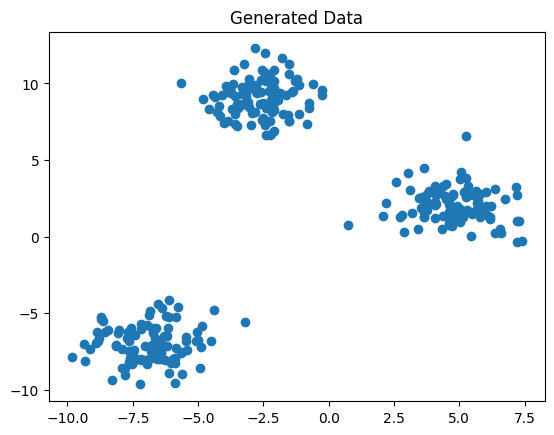

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

# Generate data
X, _ = make_blobs(n_samples=300, centers=3, cluster_std=1.2, random_state=42)

# Plot raw data
plt.scatter(X[:,0], X[:,1])
plt.title("Generated Data")
plt.show()

In [2]:
from sklearn.mixture import GaussianMixture

# Create GMM model
gmm = GaussianMixture(n_components=3, random_state=42)

# Fit model
gmm.fit(X)

# Predict cluster labels
labels = gmm.predict(X)

In [3]:
from sklearn.mixture import GaussianMixture

# Create GMM model
gmm = GaussianMixture(n_components=3, random_state=42)

# Fit model
gmm.fit(X)

# Predict cluster labels
labels = gmm.predict(X)

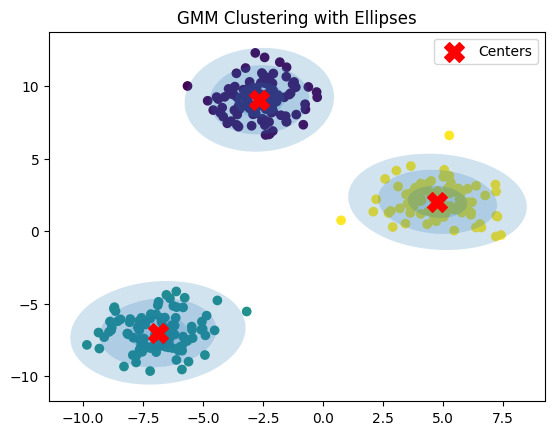

In [4]:
import matplotlib.pyplot as plt
import numpy as np

def draw_ellipse(position, covariance):
    from matplotlib.patches import Ellipse

    if covariance.shape == (2,2):
        U, s, Vt = np.linalg.svd(covariance)
        angle = np.degrees(np.arctan2(U[1,0], U[0,0]))
        width, height = 2 * np.sqrt(s)
    else:
        angle = 0
        width, height = 2 * np.sqrt(covariance)

    for nsig in range(1, 4):
        ellipse = Ellipse(position, nsig*width, nsig*height,
                          angle=angle, alpha=0.2)
        plt.gca().add_patch(ellipse)


# Scatter plot colored by cluster
plt.scatter(X[:,0], X[:,1], c=labels, cmap='viridis')

# Draw ellipses for each Gaussian
for mean, cov in zip(gmm.means_, gmm.covariances_):
    draw_ellipse(mean, cov)

# Mark centers
plt.scatter(gmm.means_[:,0], gmm.means_[:,1],
            c='red', s=200, marker='X', label='Centers')

plt.title("GMM Clustering with Ellipses")
plt.legend()
plt.show()

In [5]:
print("Means (Centers):")
print(gmm.means_)

print("\nCovariance Matrices:")
print(gmm.covariances_)

Means (Centers):
[[-2.65803969  9.04942651]
 [-6.88472071 -7.00475906]
 [ 4.76854828  2.01807919]]

Covariance Matrices:
[[[ 1.0781136   0.06290495]
  [ 0.06290495  1.42149784]]

 [[ 1.48264979  0.13786622]
  [ 0.13786622  1.41519133]]

 [[ 1.54128272 -0.14175789]
  [-0.14175789  1.22404828]]]
